In [16]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder, StandardScaler, MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
import seaborn as sns
from sklearn import metrics
import numpy as np

In [17]:
df = pd.read_csv("datasets/Heart Attack Data Set.csv")
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
1,37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
2,41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
3,56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
4,57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


In [18]:
print(f"Total Observations (rows): {df.shape[0]}")
print(f"Total Features (columns): {df.shape[1]}")

Total Observations (rows): 303
Total Features (columns): 14


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       303 non-null    int64  
 1   sex       303 non-null    int64  
 2   cp        303 non-null    int64  
 3   trestbps  303 non-null    int64  
 4   chol      303 non-null    int64  
 5   fbs       303 non-null    int64  
 6   restecg   303 non-null    int64  
 7   thalach   303 non-null    int64  
 8   exang     303 non-null    int64  
 9   oldpeak   303 non-null    float64
 10  slope     303 non-null    int64  
 11  ca        303 non-null    int64  
 12  thal      303 non-null    int64  
 13  target    303 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.3 KB


In [20]:
#Check for Duplicate Values
if (len(df[df.duplicated()])>0):
    print("Duplicate values found in the data.")
    df.drop_duplicates(inplace=True)
else:
    print("No duplicate values detected in the data.")

Duplicate values found in the data.


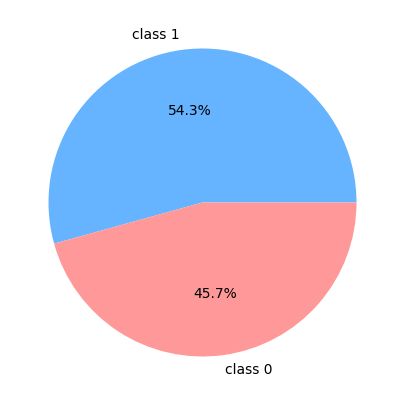

In [21]:
counts = df["target"].value_counts()

plt.figure(figsize=(5, 5))
plt.pie(x=counts.values, labels=["class " + str(target) for target in counts.keys()], autopct='%1.1f%%', colors=['#66b3ff', '#ff9999']) 
plt.show()

In [22]:
print(f"{counts[1]} observations with target '1'")
print(f"{counts[0]} observations with target '0'")

164 observations with target '1'
138 observations with target '0'


In [23]:
X = df.drop(columns=["target"])
y = df["target"]

In [24]:
for feature in X.columns:
    print(f"{feature}: {X[feature].unique()[:10]}")

age: [63 37 41 56 57 44 52 54 48 49]
sex: [1 0]
cp: [3 2 1 0]
trestbps: [145 130 120 140 172 150 110 135 160 105]
chol: [233 250 204 236 354 192 294 263 199 168]
fbs: [1 0]
restecg: [0 1 2]
thalach: [150 187 172 178 163 148 153 173 162 174]
exang: [0 1]
oldpeak: [2.3 3.5 1.4 0.8 0.6 0.4 1.3 0.  0.5 1.6]
slope: [0 2 1]
ca: [0 2 1 3 4]
thal: [1 2 3 0]


In [25]:
categorical_nominal = ["sex", "fbs", "exang", "restecg", "cp", "thal"]
categorical_ordinal = ["slope", "ca"]
bounded_numerical = ["age", "thalach", "oldpeak"]
unbounded_numerical = ["trestbps", "chol"]

## Train-Test Split

Splitting the dataset **before any preprocessing** is a deliberate choice to **prevent data leakage**.
```python
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)
```

### Parameters
- `test_size=0.2` — 20% of the data is reserved for testing, 80% for training
- `random_state=0` — ensures reproducibility of the split

### Why split before preprocessing?
Performing the train-test split **prior to any preprocessing steps** (e.g., scaling, imputation, encoding) ensures that the test set remains a truly **unseen, independent** sample.

If preprocessing were applied to the full dataset first, statistical information from the test set (such as mean, variance, or category frequencies) would **leak into the training process** — causing the model to appear more accurate than it actually is on new data.

> **Best practice:** Fit all preprocessors (e.g., `StandardScaler`, `SimpleImputer`) **only on `X_train`**, then apply (transform) them to both `X_train` and `X_test`.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

In [27]:
def one_hot_encoding(X_train: pd.DataFrame, X_test: pd.DataFrame, categorical_nominal: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, OneHotEncoder]:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    one_hot_train = encoder.fit_transform(X_train[categorical_nominal])
    one_hot_test = encoder.transform(X_test[categorical_nominal])
    ohe_cols = encoder.get_feature_names_out(categorical_nominal)
    
    X_train = pd.concat([
        X_train.drop(columns=categorical_nominal),
        pd.DataFrame(one_hot_train, columns=ohe_cols, index=X_train.index)
    ], axis=1)
    
    X_test = pd.concat([
        X_test.drop(columns=categorical_nominal),
        pd.DataFrame(one_hot_test, columns=ohe_cols, index=X_test.index)
    ], axis=1)

    return X_train, X_test, encoder

def normalization(X_train: pd.DataFrame, X_test: pd.DataFrame, bounded_numerical: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, MinMaxScaler]:
    scaler = MinMaxScaler()
    
    X_train[bounded_numerical] = scaler.fit_transform(X_train[bounded_numerical])
    X_test[bounded_numerical] = scaler.transform(X_test[bounded_numerical])
    
    return X_train, X_test, scaler

def standardization(X_train: pd.DataFrame, X_test: pd.DataFrame, unbounded_numerical: list[str]) -> tuple[pd.DataFrame, pd.DataFrame, StandardScaler]:
    scaler = StandardScaler()
    
    X_train[unbounded_numerical] = scaler.fit_transform(X_train[unbounded_numerical])
    X_test[unbounded_numerical] = scaler.transform(X_test[unbounded_numerical])

    return X_train, X_test, scaler

In [28]:
X_train, X_test, encoder = one_hot_encoding(X_train, X_test, categorical_nominal)
X_train, X_test, min_max_scaler = normalization(X_train, X_test, bounded_numerical)
X_train, X_test, standar_scaler = standardization(X_train, X_test, unbounded_numerical)

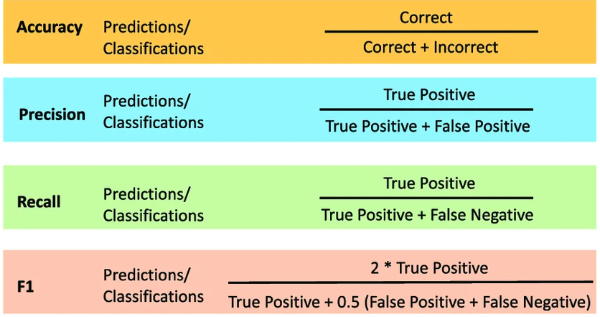

In [29]:
# The positive class is 0 because it is the rare case in the dataset

def accuracy(true_y :pd.Series, predicted_y :pd.Series) -> float:
    return (true_y == predicted_y).mean()

def precision(true_y :pd.Series, predicted_y :pd.Series) -> float:
    TP = ((true_y == 0) & (predicted_y == 0)).sum()
    FP = ((true_y == 1) & (predicted_y == 0)).sum()
    return TP / (TP + FP) if (TP + FP) > 0 else 0.0

def recall(true_y :pd.Series, predicted_y :pd.Series) -> float:
    TP = ((true_y == 0) & (predicted_y == 0)).sum()
    FN = ((true_y == 0) & (predicted_y == 1)).sum()
    return TP / (TP + FN) if (TP + FN) > 0 else 0.0

def F1_score(true_y :pd.Series, predicted_y :pd.Series) -> float:
    p = precision(true_y, predicted_y)
    r = recall(true_y, predicted_y)
    return 2 * p * r / (p + r) if (p + r) > 0 else 0.0

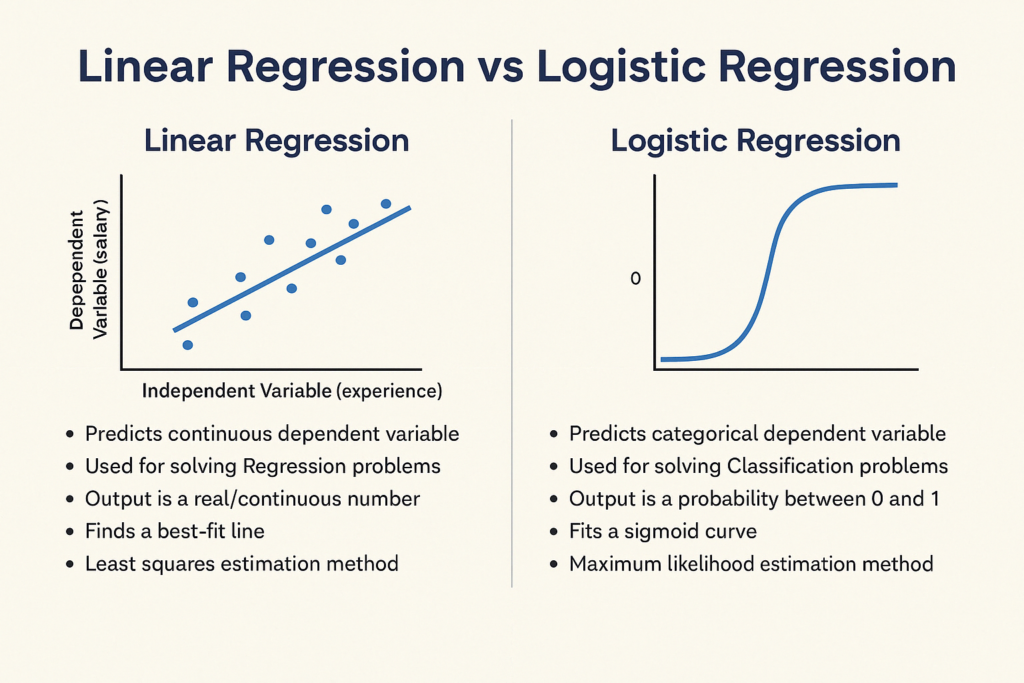

In [30]:
def sigmoid(z: pd.Series) -> pd.Series:
    return 1 / (1 + np.exp(-z))

# y_hat (prediction)
def f(X: pd.DataFrame, w: pd.Series, b: float) -> pd.Series:
    return sigmoid(X.dot(w) + b)

In [31]:
def cross_entropy_loss(y: pd.Series, y_hat: pd.Series) -> pd.Series:
    epsilon = 1e-15
    y_hat = np.clip(y_hat, epsilon, 1 - epsilon) # to avoid log(0)
    return -y * np.log(y_hat) - (1 - y) * np.log(1 - y_hat)

def cross_entropy_cost(y: pd.Series, y_hat: pd.Series) -> float:
    return cross_entropy_loss(y, y_hat).mean()

In [32]:
def db(y: pd.Series, y_hat: pd.Series) -> float:
    return (y_hat - y).mean()

def dw(X: pd.DataFrame, y: pd.Series, y_hat: pd.Series) -> pd.Series:
    return X.T.dot(y_hat - y) / len(y)

In [33]:
def gradient_descent(
    X_train: pd.DataFrame,
    y_train: pd.Series,
    X_test: pd.DataFrame,
    y_test: pd.Series,
    alpha: float = 0.05,
    max_iter: int = 500,
    epsilon: float = 1e-6,
    threshold: float = 0.5
):
    w = pd.Series(0.0, index=X_train.columns)
    b = 0.0
    nbr_iter = 0
    costs_train, costs_test = [], []
    f1_scores_train, f1_scores_test = [], []

    while nbr_iter < max_iter:
        y_hat_train = f(X_train, w, b)
        tmp_w = w - alpha * dw(X_train, y_train, y_hat_train)
        tmp_b = b - alpha * db(y_train, y_hat_train)
        w, b = tmp_w, tmp_b
        nbr_iter += 1

        y_hat_train = f(X_train, w, b)
        y_hat_test  = f(X_test,  w, b)

        f1_scores_train.append(F1_score(y_train, (y_hat_train > threshold).astype(int)))
        f1_scores_test.append(F1_score(y_test,   (y_hat_test  > threshold).astype(int)))
        costs_train.append(float(cross_entropy_cost(y_train, y_hat_train)))
        costs_test.append(float(cross_entropy_cost(y_test,  y_hat_test)))

        if nbr_iter > 1 and abs(costs_train[-2] - costs_train[-1]) < epsilon:
            break

    return w, b, f1_scores_train, f1_scores_test, costs_train, costs_test

In [34]:
# grid search
alphas     = [0.01, 0.05, 0.07, 0.1]
thresholds = [0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.65, 0.7, 0.75]

best_f1 = 0
best_params = {}

for alpha in alphas:
    for t in thresholds:
        w, b, _, f1_test, _, _ = gradient_descent(
            X_train, y_train, X_test, y_test,
            alpha=alpha,
            max_iter=500,
            threshold=t
        )
        final_f1 = f1_test[-1]
        print(f"alpha={alpha}, threshold={t} → F1 test: {final_f1:.3f}")

        if final_f1 > best_f1:
            best_f1 = final_f1
            best_params = {"alpha": alpha, "threshold": t}

print("Best Hyperparameters:", best_params)

alpha=0.01, threshold=0.3 → F1 test: 0.585
alpha=0.01, threshold=0.35 → F1 test: 0.667
alpha=0.01, threshold=0.4 → F1 test: 0.776
alpha=0.01, threshold=0.45 → F1 test: 0.800
alpha=0.01, threshold=0.5 → F1 test: 0.873
alpha=0.01, threshold=0.55 → F1 test: 0.847
alpha=0.01, threshold=0.6 → F1 test: 0.852
alpha=0.01, threshold=0.65 → F1 test: 0.825
alpha=0.01, threshold=0.7 → F1 test: 0.765
alpha=0.01, threshold=0.75 → F1 test: 0.740
alpha=0.05, threshold=0.3 → F1 test: 0.800
alpha=0.05, threshold=0.35 → F1 test: 0.800
alpha=0.05, threshold=0.4 → F1 test: 0.846
alpha=0.05, threshold=0.45 → F1 test: 0.873
alpha=0.05, threshold=0.5 → F1 test: 0.857
alpha=0.05, threshold=0.55 → F1 test: 0.862
alpha=0.05, threshold=0.6 → F1 test: 0.852
alpha=0.05, threshold=0.65 → F1 test: 0.852
alpha=0.05, threshold=0.7 → F1 test: 0.825
alpha=0.05, threshold=0.75 → F1 test: 0.800
alpha=0.07, threshold=0.3 → F1 test: 0.800
alpha=0.07, threshold=0.35 → F1 test: 0.824
alpha=0.07, threshold=0.4 → F1 test: 0.846


In [35]:
w, b, f1_scores_train, f1_scores_test, costs_train, costs_test = gradient_descent(X_train, y_train, X_test, y_test, alpha=best_params["alpha"], threshold=best_params["threshold"])

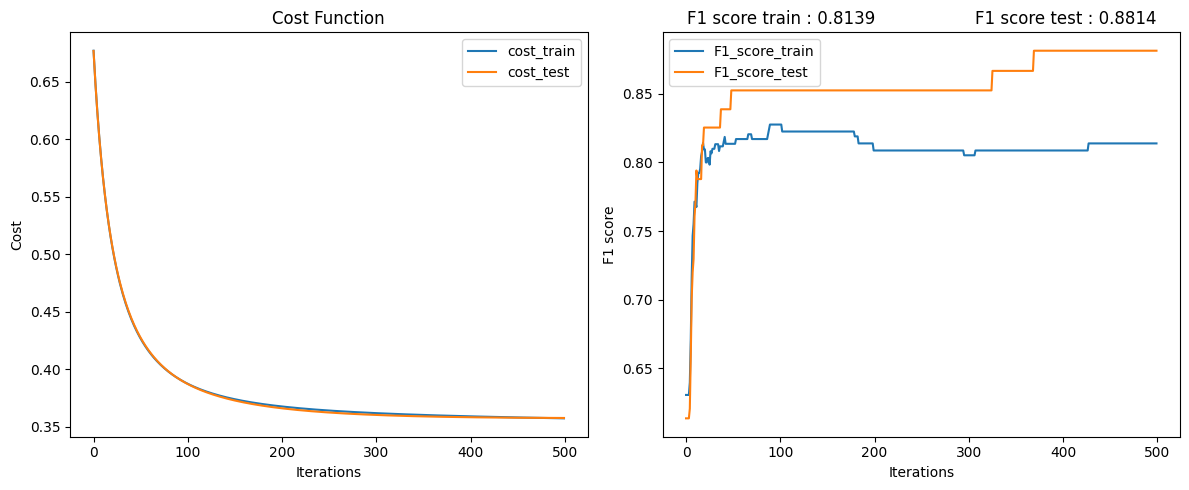

In [36]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
ax1.plot(range(len(costs_train)), costs_train, label="cost_train")
ax1.plot(range(len(costs_test)), costs_test, label="cost_test")
ax1.set_xlabel('Iterations')
ax1.set_ylabel('Cost')
ax1.set_title('Cost Function')
ax1.legend()

ax2.plot(range(len(f1_scores_train)), f1_scores_train, label="F1_score_train")
ax2.plot(range(len(f1_scores_test)), f1_scores_test, label="F1_score_test")
ax2.set_xlabel('Iterations')
ax2.set_ylabel('F1 score')
ax2.set_title(f"F1 score train : {f1_scores_train[-1]:0.4}                   F1 score test : {f1_scores_test[-1]:0.4}")
ax2.legend()

plt.tight_layout()
plt.show()

In [37]:
y_predicted = (f(X_test, w, b) > best_params['threshold']).astype(int)

print(f"y_test : {y_test[:10].to_list()}")
print(f"y_predicted : {y_predicted[:10].to_list()}")

y_test : [0, 1, 0, 0, 1, 0, 0, 0, 0, 0]
y_predicted : [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]


In [38]:
print("F1 score test: ", float(F1_score(y_test, y_predicted)))

F1 score test:  0.8813559322033898


In [39]:
model = LogisticRegression()
model.fit(X_train, y_train)

y_predicted = model.predict(X_test)

In [40]:
print("F1 score test: ", float(F1_score(y_test, y_predicted)))

F1 score test:  0.8888888888888888


Text(0.5, 427.9555555555555, 'Predicted label')

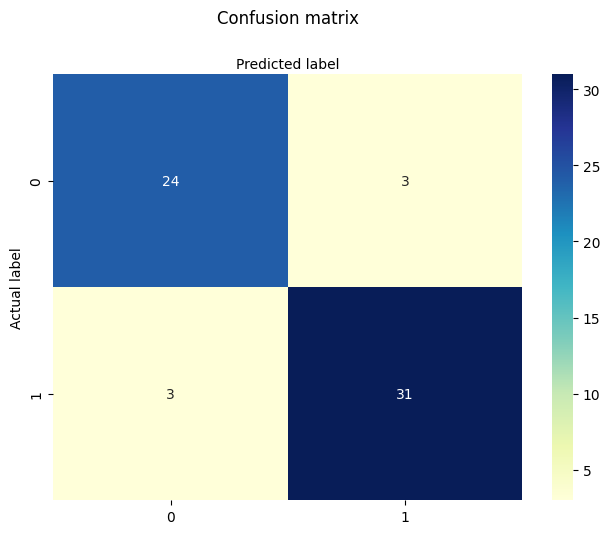

In [42]:
cnf_matrix = metrics.confusion_matrix(y_test, y_predicted)

class_names=[0,1]
fig, ax = plt.subplots()
tick_marks = np.arange(len(class_names))
plt.xticks(tick_marks, class_names)
plt.yticks(tick_marks, class_names)

sns.heatmap(pd.DataFrame(cnf_matrix), annot=True, cmap="YlGnBu" ,fmt='g')
ax.xaxis.set_label_position("top")
plt.tight_layout()
plt.title('Confusion matrix', y=1.1)
plt.ylabel('Actual label')
plt.xlabel('Predicted label')